# Estudos de adesão de arquivos de contexto de IA

Este notebook tem como objetivo analisar a presença de arquivos de contexto de IA (como `AGENTS.md`, `CLAUDE.md`, etc.) nos repositórios ranqueados. Os dados foram coletados via API do GitHub.

## Configurações

Importações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import glob
import numpy as np

Setup de visualização

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Estudo da estrutura dos dados

Nesta seção, analisamos a estrutura do arquivo gerado pela detecção de arquivos de contexto.

In [3]:
DATA_PATH = "../data/context_detection/context_api_top1000_23-03-2026.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Colunas encontradas: {df.columns.to_list()}")
    display(df.head())
else:
    print(f"Arquivo {DATA_PATH} não encontrado.")

Colunas encontradas: ['name', 'rank', 'AGENTS.md', 'CLAUDE.md', 'COPILOT', 'GEMINI.md', 'CURSOR']


,name,rank,AGENTS.md,CLAUDE.md,COPILOT,GEMINI.md,CURSOR
0,rust-lang/rust,1.0,0,0,0,0,0
1,tensorflow/tensorflow,2.0,0,0,0,0,0
2,elastic/elasticsearch,3.0,1,0,0,0,0
3,git/git,4.0,0,0,0,0,0
4,kubernetes/kubernetes,5.0,0,0,0,0,0


### Descrição das colunas

- `name`: Nome do repositório (usuário/projeto).
- `rank`: Posição do repositório no ranking de popularidade/maturidade.
- `AGENTS.md`: Indica se o arquivo `AGENTS.md` foi detectado (1) ou não (0).
- `CLAUDE.md`: Indica se o arquivo `CLAUDE.md` foi detectado (1) ou não (0).
- `COPILOT`: Indica se arquivos de configuração do GitHub Copilot foram detectados.
- `GEMINI.md`: Indica se o arquivo `GEMINI.md` foi detectado (1) ou não (0).
- `CURSOR`: Indica se arquivos de configuração do Cursor foram detectados.

## Análise de adesão

Configurando o dataframe

In [4]:
context_columns = [col for col in df.columns if col not in ['name', 'rank']]

df['has_any_context'] = df[context_columns].any(axis=1)

### Verificação de proporção de arquivos de contexto de IA nos repositórios

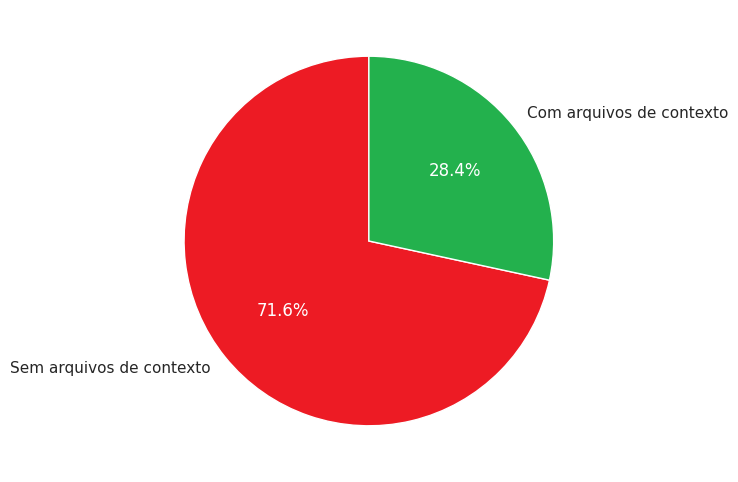

In [5]:
adoption_counts = df['has_any_context'].value_counts() # False: count, True: count
labels = ['Sem arquivos de contexto', 'Com arquivos de contexto']

plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(adoption_counts, labels=labels, autopct='%1.1f%%', colors=["#ED1B24","#23B14D"], startangle=90)
for t in autotexts:
    t.set_fontsize(12)
    t.set_color('white')
plt.show()

### Adoção por Faixa de Rank

/tmp/ipykernel_111120/2729551697.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bucket_adoption.index, y=bucket_adoption.values, palette="magma")


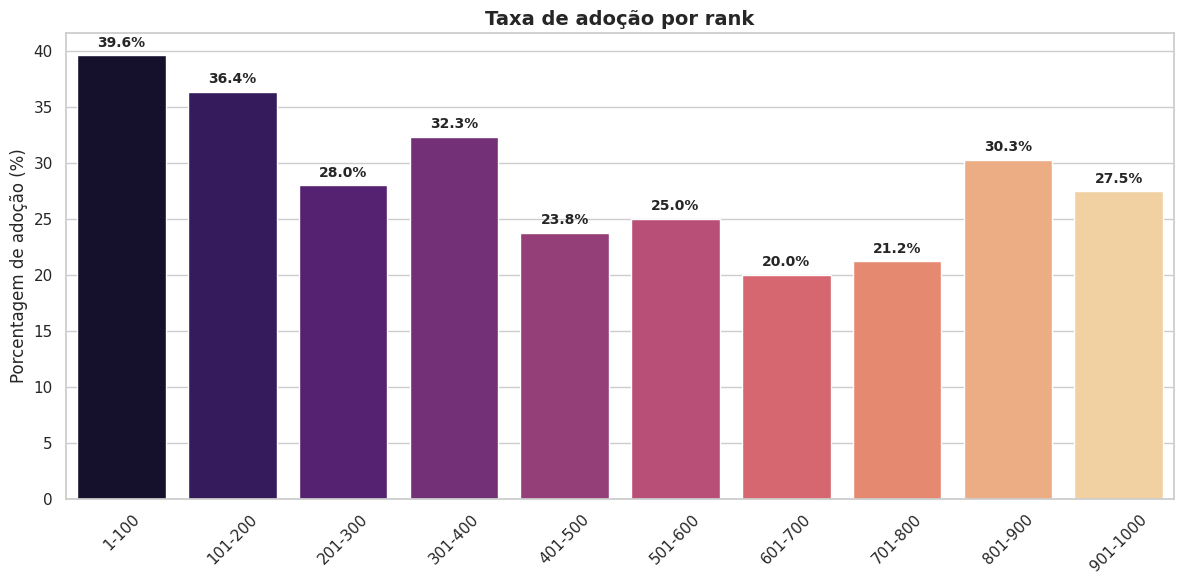

In [6]:
num_bins = 10
df['rank_bucket'] = pd.cut(df['rank'], bins=num_bins, labels=[f"{i*100+1}-{(i+1)*100}" for i in range(num_bins)])

bucket_adoption = df.groupby('rank_bucket', observed=True)['has_any_context'].mean() * 100

plt.figure(figsize=(12, 6))
plt.title("Taxa de adoção por rank", fontsize=14, fontweight='bold')
sns.barplot(x=bucket_adoption.index, y=bucket_adoption.values, palette="magma")

plt.ylabel("Porcentagem de adoção (%)")
plt.xlabel(None)
plt.xticks(rotation=45)

for i, val in enumerate(bucket_adoption.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Quantidade de arquivos por repositório

Criação de coluna para contagem de arquivos de contexto por repositório

In [7]:
df['context_count'] = df[context_columns].sum(axis=1)

/tmp/ipykernel_111120/3743193167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_dist.index, y=count_dist.values, palette="RdYlGn")


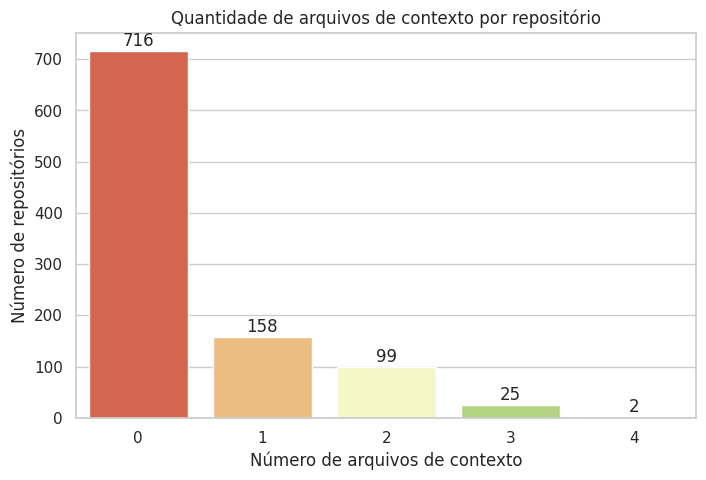

In [8]:
count_dist = df['context_count'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=count_dist.index, y=count_dist.values, palette="RdYlGn")
plt.title("Quantidade de arquivos de contexto por repositório")
plt.ylabel("Número de repositórios")
plt.xlabel("Número de arquivos de contexto")

for i, val in enumerate(count_dist.values):
    plt.text(i, val + 2, str(val), ha='center', va='bottom')

plt.show()

### Análise de arquivos de contexto conjuntos

Distribuição entre os arquivos únicos e compostos

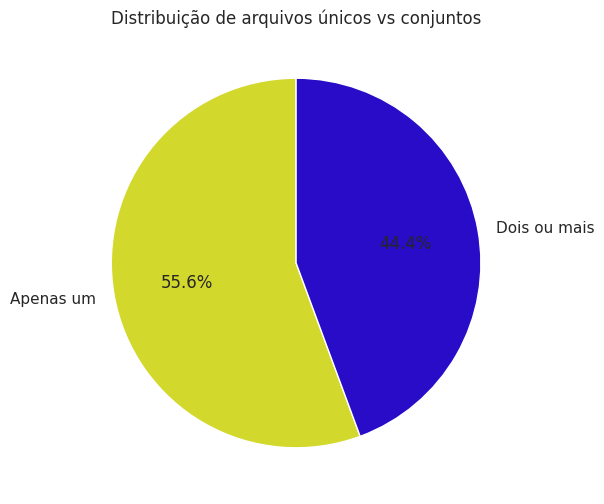

In [9]:
df_has_context = df[df['has_any_context'] == True]
multi_count_dist = (df_has_context['context_count'] >= 2).value_counts()
labels = ['Apenas um', 'Dois ou mais']

plt.figure(figsize=(6, 6))
plt.pie(multi_count_dist, labels=labels, autopct='%1.1f%%', colors=["#d3d82c","#280cc8"], startangle=90)
plt.title("Distribuição de arquivos únicos vs conjuntos")
plt.show()

Arquivos de contexto descritos por repositório

In [10]:
df_multi = df.query("context_count >= 2").copy()
print(f"Total de repositórios com dois ou mais arquivos: {len(df_multi)}")

def get_combination(row):
    return " + ".join([col for col in context_columns if row[col] == 1])

df_multi['combination'] = df_multi.apply(get_combination, axis=1)
df_multi[['name', 'combination', 'context_count']].sort_values('context_count', ascending=False).head(10)

Total de repositórios com dois ou mais arquivos: 126


,name,combination,context_count
58,apache/superset,AGENTS.md + CLAUDE.md + COPILOT + GEMINI.md,4
341,apache/grails-core,AGENTS.md + CLAUDE.md + GEMINI.md + CURSOR,4
88,huggingface/transformers,AGENTS.md + CLAUDE.md + COPILOT,3
122,vitessio/vitess,AGENTS.md + CLAUDE.md + COPILOT,3
59,seleniumhq/selenium,AGENTS.md + CLAUDE.md + COPILOT,3
11,home-assistant/core,AGENTS.md + CLAUDE.md + COPILOT,3
230,spinnaker/spinnaker,AGENTS.md + CLAUDE.md + COPILOT,3
306,mapbox/mapbox-gl-js,AGENTS.md + CLAUDE.md + GEMINI.md,3
365,internetarchive/openlibrary,AGENTS.md + CLAUDE.md + COPILOT,3
361,mautic/mautic,AGENTS.md + CLAUDE.md + GEMINI.md,3


Quantidade de repositório por composição de arquivos de IA

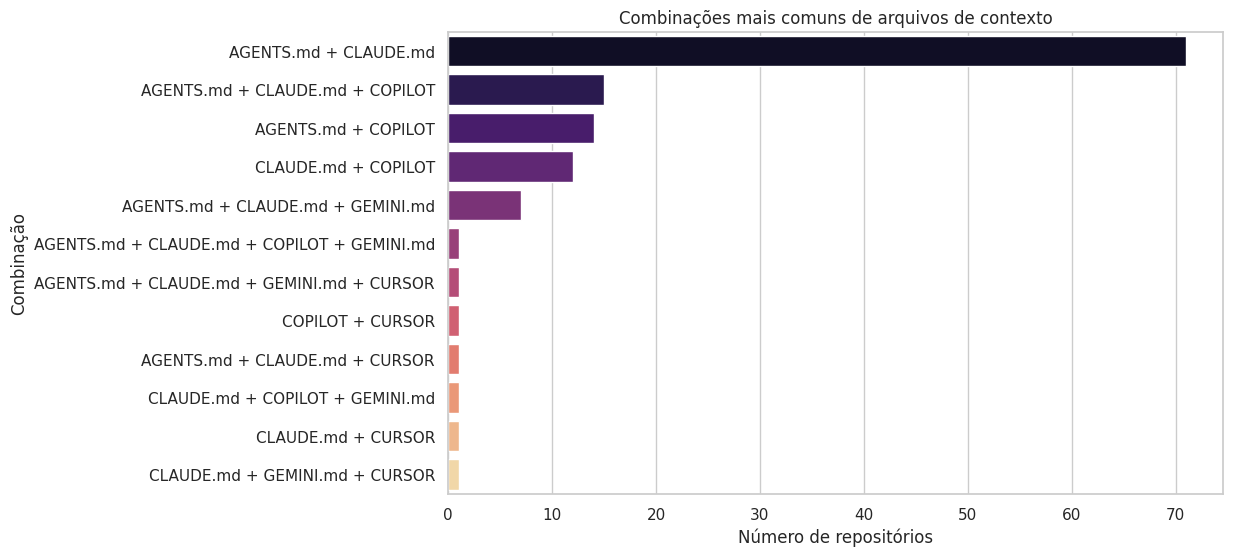

In [11]:
combination_counts = df_multi['combination'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=combination_counts.values, y=combination_counts.index, hue=combination_counts.index, palette="magma", legend=False)
plt.title("Combinações mais comuns de arquivos de contexto")
plt.xlabel("Número de repositórios")
plt.ylabel("Combinação")
plt.show()

### Frequência por tipo de arquivo

/tmp/ipykernel_111120/2385448633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=file_counts.index, y=file_counts.values, palette="viridis")


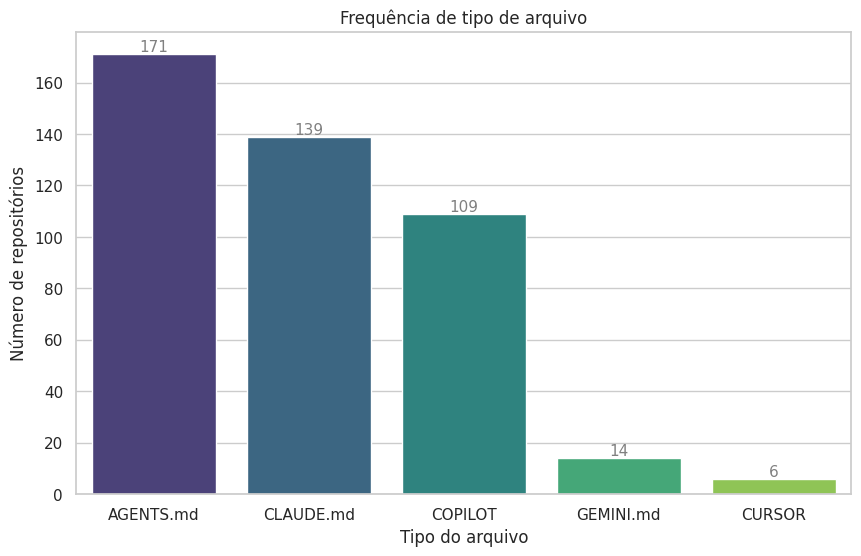

In [12]:
file_counts = df[context_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=file_counts.index, y=file_counts.values, palette="viridis")
plt.title("Frequência de tipo de arquivo")
plt.ylabel("Número de repositórios")
plt.xlabel("Tipo do arquivo")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='gray', xytext=(0, 5), 
                textcoords='offset points')

plt.show()